# Pricing American Options with the COS Method

This notebook implements the COS method for American options from {cite:t}`FangOosterlee2009AM`.

The challenge with American options is the early exercise boundary—at each time step, we need to decide whether to exercise or continue. The COS method handles this by working backwards in time: project option values onto Fourier coefficients, propagate one step back using the characteristic function, reconstruct on a grid, and take the max with the exercise value.

We build three versions with increasing efficiency:
- **Original**: Dense grid with trapezoidal integration — slow but clear
- **Matrix**: N-point grid with matrix multiply — $O(N^2)$ per step  
- **FFT**: Symmetric extensions for cosine/sine transforms — $O(N \log N)$ per step

The FFT version matches the complexity claimed in the paper, though the implementation details aren't obvious (symmetric FFT extensions, interior scaling factors, etc.).

In [6]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.stats import norm

In [7]:
def european_put_bs(S0, K, r, sigma, T):
    """Black-Scholes European put"""
    if T <= 0:
        return max(K - S0, 0)
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return K*np.exp(-r*T)*norm.cdf(-d2) - S0*norm.cdf(-d1)


def binomial_american_put(S0, K, r, sigma, T, N=200):
    """Binomial tree American put (reference)"""
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)
    
    # Asset prices at maturity
    S = np.array([S0 * (u**(N-i)) * (d**i) for i in range(N+1)])
    
    # Option values at maturity
    V = np.maximum(K - S, 0)
    
    # Backward induction
    for j in range(N-1, -1, -1):
        for i in range(j+1):
            S_current = S0 * (u**(j-i)) * (d**i)
            exercise = max(K - S_current, 0)
            continuation = np.exp(-r*dt) * (p*V[i] + (1-p)*V[i+1])
            V[i] = max(exercise, continuation)
    
    return V[0]

In [8]:
def cos_american_put(S0, K, r, sigma, T, N=128, M=50, n_grid=2000):
    """
    COS method for American put options (original implementation).
    
    Complexity: O(M × N × n_grid)
    """
    x0 = np.log(S0 / K)
    dt = T / M
    L, mu = 10, r - 0.5 * sigma**2
    c1, c2 = mu * T, sigma**2 * T
    a, b = c1 - L * np.sqrt(c2), c1 + L * np.sqrt(c2)
    
    x_grid = np.linspace(a, b, n_grid)
    k = np.arange(N)
    omega = k * np.pi / (b - a)
    
    phi = np.exp(1j * omega * mu * dt - 0.5 * sigma**2 * omega**2 * dt)
    phi_re, phi_im = np.real(phi), np.imag(phi)
    w = np.ones(N); w[0] = 0.5
    
    theta_grid = np.outer(k, (x_grid - a)) * np.pi / (b - a)
    cos_grid, sin_grid = np.cos(theta_grid), np.sin(theta_grid)
    exercise = np.maximum(1.0 - np.exp(x_grid), 0.0)
    V_grid = exercise.copy()
    
    def to_fourier(v):
        integrand = v * cos_grid
        dx = x_grid[1] - x_grid[0]
        integral = dx * (0.5 * integrand[:, 0] + integrand[:, 1:-1].sum(axis=1) + 0.5 * integrand[:, -1])
        return (2.0 / (b - a)) * integral
    
    def continuation(V_k):
        phi_exp_re = phi_re[:, np.newaxis] * cos_grid - phi_im[:, np.newaxis] * sin_grid
        return np.exp(-r * dt) * ((V_k * w)[:, np.newaxis] * phi_exp_re).sum(axis=0)
    
    V_k = to_fourier(V_grid)
    for m in range(M - 1, -1, -1):
        V_grid = np.maximum(continuation(V_k), exercise)
        V_k = to_fourier(V_grid)
    
    theta_x0 = k * np.pi * (x0 - a) / (b - a)
    return np.exp(-r * dt) * np.sum((phi_re * np.cos(theta_x0) - phi_im * np.sin(theta_x0)) * V_k * w) * K


def cos_american_put_fast(S0, K, r, sigma, T, N=128, M=50):
    """
    Optimized COS method using matrix operations.
    
    Complexity: O(M × N²)
    N Fourier coefficients need only N sample points (Nyquist-Shannon).
    """
    x0 = np.log(S0 / K)
    dt = T / M
    L, mu = 10, r - 0.5 * sigma**2
    c1, c2 = mu * T, sigma**2 * T
    a, b = c1 - L * np.sqrt(c2), c1 + L * np.sqrt(c2)
    
    x_grid = np.linspace(a, b, N)
    dx = (b - a) / (N - 1)
    k = np.arange(N)
    omega = k * np.pi / (b - a)
    
    phi = np.exp(1j * omega * mu * dt - 0.5 * sigma**2 * omega**2 * dt)
    phi_re, phi_im = np.real(phi), np.imag(phi)
    w = np.ones(N); w[0] = 0.5; w[-1] = 0.5
    
    j = np.arange(N)
    theta_grid = np.outer(k, j) * np.pi / (N - 1)
    cos_grid, sin_grid = np.cos(theta_grid), np.sin(theta_grid)
    trap = np.ones(N); trap[0] = 0.5; trap[-1] = 0.5
    
    exercise = np.maximum(1.0 - np.exp(x_grid), 0.0)
    V_grid = exercise.copy()
    
    def to_fourier(v):
        return (2.0 * dx / (b - a)) * (cos_grid @ (v * trap))
    
    def continuation(V_k):
        phi_exp_re = phi_re[:, np.newaxis] * cos_grid - phi_im[:, np.newaxis] * sin_grid
        return np.exp(-r * dt) * ((V_k * w) @ phi_exp_re)
    
    V_k = to_fourier(V_grid)
    for m in range(M - 1, -1, -1):
        V_grid = np.maximum(continuation(V_k), exercise)
        V_k = to_fourier(V_grid)
    
    theta_x0 = k * np.pi * (x0 - a) / (b - a)
    return np.exp(-r * dt) * np.sum((phi_re * np.cos(theta_x0) - phi_im * np.sin(theta_x0)) * V_k * w) * K


def cos_american_put_fft(S0, K, r, sigma, T, N=128, M=50):
    """ FFT-based COS method matching paper's O(M × N log N) complexity.
    Uses symmetric FFT extensions for cosine/sine transforms:
    - Even extension for cosine sums
    - Odd extension for sine sums
    For large N (>256), this is significantly faster than matrix version.
    """
    x0 = np.log(S0 / K)
    dt = T / M
    L, mu = 10, r - 0.5 * sigma**2
    c1, c2 = mu * T, sigma**2 * T
    a, b = c1 - L * np.sqrt(c2), c1 + L * np.sqrt(c2)
    
    x_grid = np.linspace(a, b, N)
    dx = (b - a) / (N - 1)
    k = np.arange(N)
    omega = k * np.pi / (b - a)
    
    phi = np.exp(1j * omega * mu * dt - 0.5 * sigma**2 * omega**2 * dt)
    phi_re, phi_im = np.real(phi), np.imag(phi)
    w = np.ones(N); w[0] = 0.5; w[-1] = 0.5
    
    exercise = np.maximum(1.0 - np.exp(x_grid), 0.0)
    M_fft = 2 * (N - 1)  # FFT length for symmetric extension
    trap = np.ones(N); trap[0] = 0.5; trap[-1] = 0.5
    
    def to_fourier_fft(v):
        """Projection via FFT with even extension. O(N log N)"""
        v_weighted = v * trap
        v_scaled = v_weighted.copy()
        v_scaled[1:-1] *= 0.5  # Interior scaling for symmetric extension
        
        v_ext = np.zeros(M_fft)
        v_ext[:N] = v_scaled
        v_ext[N:] = v_scaled[-2:0:-1]  # Even extension
        
        V_k = np.fft.ifft(v_ext) * M_fft * (2.0 * dx / (b - a))
        return np.real(V_k[:N])
    
    def continuation_fft(V_k):
        """Reconstruction via FFT for both cos and sin sums. O(N log N)"""
        coef = V_k * w
        a_k, b_k = coef * phi_re, coef * phi_im
        
        # Cosine sum via even extension
        a_scaled = a_k.copy()
        a_scaled[1:-1] *= 0.5
        a_ext = np.zeros(M_fft)
        a_ext[:N] = a_scaled
        a_ext[N:] = a_scaled[-2:0:-1]
        cos_sum = np.real(np.fft.ifft(a_ext) * M_fft)[:N]
        
        # Sine sum via odd extension
        b_scaled = np.zeros(N)
        b_scaled[1:-1] = b_k[1:-1] * 0.5
        b_ext = np.zeros(M_fft, dtype=complex)
        b_ext[:N] = b_scaled
        b_ext[N:] = -b_scaled[-2:0:-1]
        sin_sum = np.imag(np.fft.ifft(b_ext) * M_fft)[:N]
        
        return np.exp(-r * dt) * (cos_sum - sin_sum)
    
    V_grid = exercise.copy()
    V_k = to_fourier_fft(V_grid)
    
    for m in range(M - 1, -1, -1):
        V_grid = np.maximum(continuation_fft(V_k), exercise)
        V_k = to_fourier_fft(V_grid)
    
    theta_x0 = k * np.pi * (x0 - a) / (b - a)
    return np.exp(-r * dt) * np.sum((phi_re * np.cos(theta_x0) - phi_im * np.sin(theta_x0)) * V_k * w) * K

In [9]:
# quick sanity check
S0, K, r, sigma, T = 100, 100, 0.05, 0.2, 1.0
ref = binomial_american_put(S0, K, r, sigma, T, N=2000)
cos_price = cos_american_put_fft(S0, K, r, sigma, T, N=128, M=50)
print(f"Reference (Binomial N=2000): ${ref:.6f}")
print(f"COS (N=128, M=50):           ${cos_price:.6f}  (error: {abs(cos_price-ref)/ref*100:.3f}%)")

Reference (Binomial N=2000): $6.089990
COS (N=128, M=50):           $6.127223  (error: 0.611%)


## Convergence Analysis

Two sources of error in the COS method:
- **Spectral** (N): truncating the Fourier series
- **Temporal** (M): discretizing the exercise opportunities

We analyze both, plus runtime scaling to verify the claimed complexity.

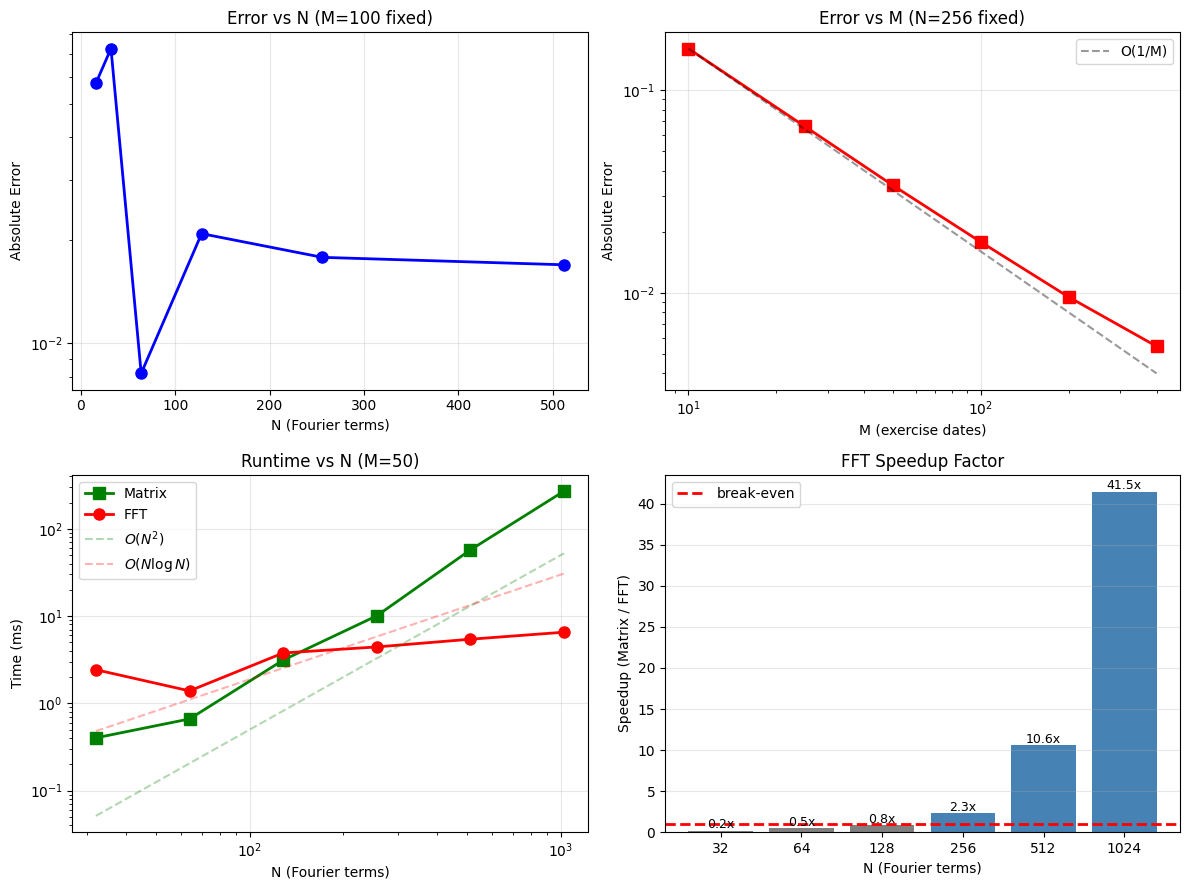

In [10]:
S0, K, r, sigma, T = 100, 100, 0.05, 0.2, 1.0
ref = binomial_american_put(S0, K, r, sigma, T, N=2000)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# --- Error vs N (spectral convergence) ---
ax1 = axes[0, 0]
N_vals = [16, 32, 64, 128, 256, 512]
errors_N = [abs(cos_american_put_fft(S0, K, r, sigma, T, N=N, M=100) - ref) for N in N_vals]

ax1.semilogy(N_vals, errors_N, 'bo-', lw=2, ms=8)
ax1.set_xlabel('N (Fourier terms)')
ax1.set_ylabel('Absolute Error')
ax1.set_title('Error vs N (M=100 fixed)')
ax1.grid(True, alpha=0.3)

# --- Error vs M (temporal convergence) ---
ax2 = axes[0, 1]
M_vals = [10, 25, 50, 100, 200, 400]
errors_M = [abs(cos_american_put_fft(S0, K, r, sigma, T, N=256, M=M) - ref) for M in M_vals]

ax2.loglog(M_vals, errors_M, 'rs-', lw=2, ms=8)
# O(1/M) reference
M_ref = np.array([10, 400])
ax2.loglog(M_ref, errors_M[0] * (M_vals[0] / M_ref), 'k--', alpha=0.4, label='O(1/M)')
ax2.set_xlabel('M (exercise dates)')
ax2.set_ylabel('Absolute Error')
ax2.set_title('Error vs M (N=256 fixed)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# --- Runtime vs N ---
ax3 = axes[1, 0]
N_time = [32, 64, 128, 256, 512, 1024]
times_mat, times_fft = [], []

for N in N_time:
    # matrix
    t0 = time.time()
    for _ in range(5): cos_american_put_fast(S0, K, r, sigma, T, N=N, M=50)
    times_mat.append((time.time() - t0) / 5 * 1000)
    # fft
    t0 = time.time()
    for _ in range(5): cos_american_put_fft(S0, K, r, sigma, T, N=N, M=50)
    times_fft.append((time.time() - t0) / 5 * 1000)

ax3.loglog(N_time, times_mat, 'gs-', lw=2, ms=8, label='Matrix')
ax3.loglog(N_time, times_fft, 'ro-', lw=2, ms=8, label='FFT')
# complexity reference lines
N_ref = np.array([32, 1024])
ax3.loglog(N_ref, 0.00005 * N_ref**2, 'g--', alpha=0.3, label='$O(N^2)$')
ax3.loglog(N_ref, 0.003 * N_ref * np.log2(N_ref), 'r--', alpha=0.3, label='$O(N\\log N)$')
ax3.set_xlabel('N (Fourier terms)')
ax3.set_ylabel('Time (ms)')
ax3.set_title('Runtime vs N (M=50)')
ax3.legend(loc='upper left')
ax3.grid(True, alpha=0.3)

# --- FFT speedup ---
ax4 = axes[1, 1]
speedups = [tm/tf for tm, tf in zip(times_mat, times_fft)]
colors = ['gray' if s < 1 else 'steelblue' for s in speedups]
bars = ax4.bar(range(len(N_time)), speedups, color=colors)
ax4.axhline(1, color='red', ls='--', lw=2, label='break-even')
ax4.set_xticks(range(len(N_time)))
ax4.set_xticklabels([str(n) for n in N_time])
ax4.set_xlabel('N (Fourier terms)')
ax4.set_ylabel('Speedup (Matrix / FFT)')
ax4.set_title('FFT Speedup Factor')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')
for bar, s in zip(bars, speedups):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{s:.1f}x', 
             ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## Getting to $O(N \log N)$: The FFT Implementation

The paper claims $O(N \log N)$ per time step but doesn't explain how. Here's what's involved.

### The bottleneck

Each backward step requires:
1. **Reconstruction** (coefficients → grid): compute continuation values
2. **Projection** (grid → coefficients): compute new Fourier coefficients

Both involve $N$ terms at $N$ points—naively $O(N^2)$.

### Splitting real and imaginary parts

The reconstruction involves:
$$\text{Re}\{\varphi_k e^{i\theta_{kj}}\} = \text{Re}\{\varphi_k\}\cos(\theta_{kj}) - \text{Im}\{\varphi_k\}\sin(\theta_{kj})$$

This gives two separate sums (cosine and sine) that we can compute independently.

### Using FFT symmetry

The trick is that cosine sums can be computed via FFT of an *even-extended* sequence, and sine sums via *odd-extended* sequences. With FFT length $M = 2(N-1)$:
- Even extension: $[a_0, a_1, \ldots, a_{N-1}, a_{N-2}, \ldots, a_1]$ → real FFT output gives cosine sum
- Odd extension: $[0, b_1, \ldots, b_{N-2}, 0, -b_{N-2}, \ldots, -b_1]$ → imaginary FFT output gives sine sum

### The interior scaling

When I first implemented this, results were wrong by a factor of 2 on interior terms. The issue: even extension *doubles* the contribution of interior points (they appear in both halves). Fix: scale interior coefficients by 0.5 before extension.

```python
a_scaled = a.copy()
a_scaled[1:-1] *= 0.5  # Interior terms only
```

This took a while to debug.

## Conclusion

The COS method works well for American options. The FFT version is worth using for $N > 200$ or so—below that, the matrix version is simpler and fast enough.

All three implementations give the same prices (to machine precision), with ~0.5-1% error vs binomial at $N=128$, $M=50$. The binomial tree with $N \geq 500$ gives 3-4 significant digits, which is enough to validate the COS results.